# Intro

## Global parameters

In [1]:
MAX_TIME_HOURS=1
ALPHA=0.01

## Modules

### Standard

In [2]:
import os, pickle, platform, sys
import numpy as np

In [3]:
from collections import defaultdict

In [4]:
import dcms
from dcms.models import DCMModel, DECMModel, qDECMModel, DWCMModel

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [6]:
from scipy.stats import spearmanr

In [7]:
from tqdm.notebook import tqdm, trange

In [8]:
import datetime as dt

In [9]:
from bowtie import edges2bowtie

### Home made

In [10]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")

sys.path.insert(0, HOME)

Stella!


In [11]:
from auxiliary_functions import el2ks

In [12]:
from sam_bowtie import block_and_fluxes as bnf

## Load data

In [13]:
DATA_FOLDER=HOME+'dati_elezioni/'
TEST_FOLDER=HOME+'tests/'
PVALUE_FOLDER=HOME+'pvalues/'

### Original data

In [14]:
files=os.listdir(DATA_FOLDER)
files.sort()

In [15]:
files

['crisi_dicos.csv',
 'crisi_weighted_edgelist.csv',
 'ita_elections_dicos.csv',
 'ita_elections_weighted_edgelist.csv',
 'quirinale_dicos.csv',
 'quirinale_weighted_edgelist.csv']

In [16]:
l_dataset=len(files)//2

# P-value validation

## FDR function

In [17]:
def fdr(p_vals_list, alpha=0.01):
    p_vals_array = np.array(p_vals_list)
    sorted_indices = np.argsort(p_vals_array)
    sorted_p_vals = p_vals_array[sorted_indices]
    m = len(p_vals_array)
    threshold = np.arange(1, m + 1) * alpha / m
    below_threshold = sorted_p_vals <= threshold
    if not np.any(below_threshold):
        return 0
    max_index = np.max(np.where(below_threshold))
    return threshold[max_index]

## P-value validation

### Fluxes

In [18]:
p_vals_files=os.listdir(PVALUE_FOLDER)
p_vals_files.sort()

In [19]:
fluxes_dict=defaultdict(dict)
for p_val_file in p_vals_files:
    if p_val_file.endswith('fluxes.pkl'):
        with open(PVALUE_FOLDER + '/' + p_val_file, 'rb') as f:
            _p_vals = pickle.load(f)
        p_vals_list=[]
        for key, value in _p_vals.items():
            p_vals_list.append(value['p_value'])
        threshold = fdr(p_vals_list, alpha=ALPHA)
        p_vals_list = np.array(p_vals_list)
        validated_ratio=np.sum(p_vals_list<=threshold)
        key=p_val_file.replace('_pvalues_fluxes.pkl', '')
        fluxes_dict[key]['p_vals'] = _p_vals
        fluxes_dict[key][f'FDR_{ALPHA}'] = threshold
        fluxes_dict[key]['validated_ratio'] = validated_ratio/len(p_vals_list)
        print(f"{key}: validated_ratio={fluxes_dict[key]['validated_ratio']:.3f}")

        

crisi_dico0: validated_ratio=0.980
crisi_dico1: validated_ratio=0.898
crisi_dico2: validated_ratio=0.980
crisi_dico3: validated_ratio=0.867
crisi_dico4: validated_ratio=0.778
ita_elections_dico0: validated_ratio=0.898
ita_elections_dico1: validated_ratio=0.939
ita_elections_dico2: validated_ratio=0.918
ita_elections_dico3: validated_ratio=1.000
ita_elections_dico4: validated_ratio=0.796
ita_elections_dico5: validated_ratio=0.833
ita_elections_dico6: validated_ratio=0.833
quirinale_dico0: validated_ratio=0.918
quirinale_dico1: validated_ratio=0.810
quirinale_dico2: validated_ratio=0.878
quirinale_dico3: validated_ratio=0.800
quirinale_dico4: validated_ratio=0.918
quirinale_dico5: validated_ratio=0.857
quirinale_dico6: validated_ratio=0.776


In [20]:
fluxes_dict_0=defaultdict(dict)
for p_val_file in p_vals_files:
    if p_val_file.endswith('fluxes_0.pkl'):
        with open(PVALUE_FOLDER + '/' + p_val_file, 'rb') as f:
            _p_vals = pickle.load(f)
        p_vals_list=[]
        for key, value in _p_vals.items():
            p_vals_list.append(value['p_value'])
        threshold = fdr(p_vals_list, alpha=ALPHA)
        p_vals_list = np.array(p_vals_list)
        validated_ratio=np.sum(p_vals_list<=threshold)
        key=p_val_file.replace('_pvalues_fluxes_0.pkl', '')
        fluxes_dict_0[key]['p_vals'] = _p_vals
        fluxes_dict_0[key][f'FDR_{ALPHA}'] = threshold
        fluxes_dict_0[key]['validated_ratio'] = validated_ratio/len(p_vals_list)
        print(f"{key}: validated_ratio={fluxes_dict_0[key]['validated_ratio']:.3f}")

        

crisi_dico0: validated_ratio=0.980
crisi_dico1: validated_ratio=0.878
crisi_dico2: validated_ratio=0.980
crisi_dico3: validated_ratio=0.867
crisi_dico4: validated_ratio=0.778
ita_elections_dico0: validated_ratio=0.898
ita_elections_dico1: validated_ratio=0.918
ita_elections_dico2: validated_ratio=0.918
ita_elections_dico3: validated_ratio=1.000
ita_elections_dico4: validated_ratio=0.796
ita_elections_dico5: validated_ratio=0.733
ita_elections_dico6: validated_ratio=0.833
quirinale_dico0: validated_ratio=0.918
quirinale_dico1: validated_ratio=0.810
quirinale_dico2: validated_ratio=0.878
quirinale_dico3: validated_ratio=0.800
quirinale_dico4: validated_ratio=0.918
quirinale_dico5: validated_ratio=0.857
quirinale_dico6: validated_ratio=0.776


#### Differences?

In [21]:
for key in fluxes_dict.keys():
    p_vals=fluxes_dict[key]['p_vals']
    fdr_th=fluxes_dict[key][f'FDR_{ALPHA}']
    fluxes=list(p_vals.keys())
    p_vals=np.array([p_vals[f]['p_value'] for f in fluxes])
    fdr_mask=p_vals<=fdr_th

    p_vals_0=fluxes_dict_0[key]['p_vals']
    fdr_th_0=fluxes_dict_0[key][f'FDR_{ALPHA}']
    p_vals_0=np.array([p_vals_0[f]['p_value'] for f in fluxes])
    fdr_mask_0=p_vals_0<=fdr_th_0

    if np.all(fdr_mask==fdr_mask_0):
        print(f"{key}: FDR masks are the same.")
    else:
        diff_indices = np.where(fdr_mask != fdr_mask_0)[0]

        print(f"{key}: FDR masks differ at:")
        for diff_index in diff_indices:
            print(f"  Index {diff_index}: {fluxes[diff_index]}: p-value={p_vals[diff_index]} vs. {p_vals_0[diff_index]}")

crisi_dico0: FDR masks are the same.
crisi_dico1: FDR masks differ at:
  Index 8: (np.str_('OUTTENDRILS'), np.str_('OUT')): p-value=0.007 vs. 0.0096
crisi_dico2: FDR masks are the same.
crisi_dico3: FDR masks are the same.
crisi_dico4: FDR masks are the same.
ita_elections_dico0: FDR masks are the same.
ita_elections_dico1: FDR masks differ at:
  Index 8: (np.str_('SCC'), np.str_('SCC')): p-value=0.006 vs. 0.0156
ita_elections_dico2: FDR masks are the same.
ita_elections_dico3: FDR masks are the same.
ita_elections_dico4: FDR masks are the same.
ita_elections_dico5: FDR masks differ at:
  Index 2: (np.str_('SCC'), np.str_('SCC')): p-value=0.0 vs. 0.1568
ita_elections_dico6: FDR masks are the same.
quirinale_dico0: FDR masks differ at:
  Index 6: (np.str_('SCC'), np.str_('OUT')): p-value=0.008 vs. 0.0096
  Index 16: (np.str_('OUTTENDRILS'), np.str_('TUBES')): p-value=0.01 vs. 0.0084
quirinale_dico1: FDR masks are the same.
quirinale_dico2: FDR masks are the same.
quirinale_dico3: FDR ma

Among the two, I tend to trust more the one with a greater statistics, i.e. the "0"-version. Nevertheless, the issue is not resolved until I have the counts for the two cases. The only difficult "ones", indeed, are "ita_elections_dico1" and "ita_elections_dico5" as the difference is particularly strong.

#### Validated fluxes and in which direction

In [22]:
for key in fluxes_dict_0.keys():
    p_vals_0=fluxes_dict_0[key]['p_vals']
    fluxes=list(p_vals_0.keys())
    fdr_th_0=fluxes_dict_0[key][f'FDR_{ALPHA}']
    tails_0=np.array([p_vals_0[f]['tail'] for f in fluxes])
    p_vals_0=np.array([p_vals_0[f]['p_value'] for f in fluxes])
    
    fdr_mask_0=p_vals_0<=fdr_th_0

    print(f"\n{key}: FDR mask 0 has {np.sum(fdr_mask_0)} validated fluxes (FDR threshold({ALPHA:.2e})={fdr_th_0:.2e}):")
    for i in range(len(fluxes)):
        if fdr_mask_0[i] and tails_0[i]=='right':
            print(f" {fluxes[i]}: p-value={p_vals_0[i]:.2e}, tail={tails_0[i]}")



crisi_dico0: FDR mask 0 has 48 validated fluxes (FDR threshold(1.00e-02)=9.80e-03):
 ('SCC', 'SCC'): p-value=0.00e+00, tail=right
 ('SCC', 'OUT'): p-value=0.00e+00, tail=right
 ('IN', 'INTENDRILS'): p-value=0.00e+00, tail=right
 ('IN', 'TUBES'): p-value=0.00e+00, tail=right
 ('OUT', 'OUT'): p-value=0.00e+00, tail=right
 ('IN', 'IN'): p-value=0.00e+00, tail=right
 ('OUTTENDRILS', 'OTHERS'): p-value=0.00e+00, tail=right
 ('OUTTENDRILS', 'INTENDRILS'): p-value=0.00e+00, tail=right
 ('OUTTENDRILS', 'OUTTENDRILS'): p-value=0.00e+00, tail=right
 ('INTENDRILS', 'INTENDRILS'): p-value=0.00e+00, tail=right
 ('TUBES', 'INTENDRILS'): p-value=0.00e+00, tail=right
 ('OUTTENDRILS', 'TUBES'): p-value=0.00e+00, tail=right
 ('OTHERS', 'OTHERS'): p-value=0.00e+00, tail=right
 ('TUBES', 'TUBES'): p-value=0.00e+00, tail=right
 ('OTHERS', 'INTENDRILS'): p-value=0.00e+00, tail=right

crisi_dico1: FDR mask 0 has 43 validated fluxes (FDR threshold(1.00e-02)=8.78e-03):
 ('IN', 'OUT'): p-value=0.00e+00, tail=r

### Blocks

In [23]:
block_dict=defaultdict(dict)
for p_val_file in p_vals_files:
    if p_val_file.endswith('blocks.pkl'):
        with open(PVALUE_FOLDER + '/' + p_val_file, 'rb') as f:
            _p_vals = pickle.load(f)
        p_vals_list=[]
        for key, value in _p_vals.items():
            p_vals_list.append(value['p_value'])
        threshold = fdr(p_vals_list, alpha=ALPHA)
        p_vals_list = np.array(p_vals_list)
        validated_ratio=np.sum(p_vals_list<=threshold)
        key=p_val_file.replace('_pvalues_blocks.pkl', '')
        block_dict[key]['p_vals'] = _p_vals
        block_dict[key][f'FDR_{ALPHA}'] = threshold
        block_dict[key]['validated_ratio'] = validated_ratio/len(p_vals_list)
        print(f"{key}: validated_ratio={block_dict[key]['validated_ratio']:.3f}")

crisi_dico0: validated_ratio=1.000
crisi_dico1: validated_ratio=1.000
crisi_dico2: validated_ratio=0.857
crisi_dico3: validated_ratio=0.429
crisi_dico4: validated_ratio=0.571
ita_elections_dico0: validated_ratio=0.857
ita_elections_dico1: validated_ratio=0.714
ita_elections_dico2: validated_ratio=0.857
ita_elections_dico3: validated_ratio=1.000
ita_elections_dico4: validated_ratio=0.429
ita_elections_dico5: validated_ratio=0.714
ita_elections_dico6: validated_ratio=0.429
quirinale_dico0: validated_ratio=0.857
quirinale_dico1: validated_ratio=0.571
quirinale_dico2: validated_ratio=0.714
quirinale_dico3: validated_ratio=0.429
quirinale_dico4: validated_ratio=0.857
quirinale_dico5: validated_ratio=0.286
quirinale_dico6: validated_ratio=0.000


In [24]:
block_dict_0=defaultdict(dict)
for p_val_file in p_vals_files:
    if p_val_file.endswith('blocks_0.pkl'):
        with open(PVALUE_FOLDER + '/' + p_val_file, 'rb') as f:
            _p_vals = pickle.load(f)
        p_vals_list=[]
        for key, value in _p_vals.items():
            p_vals_list.append(value['p_value'])
        threshold = fdr(p_vals_list, alpha=ALPHA)
        p_vals_list = np.array(p_vals_list)
        validated_ratio=np.sum(p_vals_list<=threshold)
        key=p_val_file.replace('_pvalues_blocks_0.pkl', '')
        block_dict_0[key]['p_vals'] = _p_vals
        block_dict_0[key][f'FDR_{ALPHA}'] = threshold
        block_dict_0[key]['validated_ratio'] = validated_ratio/len(p_vals_list)
        print(f"{key}: validated_ratio={block_dict_0[key]['validated_ratio']:.3f}")

        

crisi_dico0: validated_ratio=1.000
crisi_dico1: validated_ratio=1.000
crisi_dico2: validated_ratio=0.857
crisi_dico3: validated_ratio=0.429
crisi_dico4: validated_ratio=0.571
ita_elections_dico0: validated_ratio=0.857
ita_elections_dico1: validated_ratio=0.714
ita_elections_dico2: validated_ratio=0.857
ita_elections_dico3: validated_ratio=1.000
ita_elections_dico4: validated_ratio=0.429
ita_elections_dico5: validated_ratio=0.286
ita_elections_dico6: validated_ratio=0.571
quirinale_dico0: validated_ratio=0.857
quirinale_dico1: validated_ratio=0.571
quirinale_dico2: validated_ratio=0.714
quirinale_dico3: validated_ratio=0.429
quirinale_dico4: validated_ratio=0.857
quirinale_dico5: validated_ratio=0.286
quirinale_dico6: validated_ratio=0.000


#### Differences?

In [25]:
for key in block_dict.keys():
    p_vals=block_dict[key]['p_vals']
    fdr_th=block_dict[key][f'FDR_{ALPHA}']
    blocks=list(p_vals.keys())
    p_vals=np.array([p_vals[f]['p_value'] for f in blocks])
    fdr_mask=p_vals<=fdr_th

    p_vals_0=block_dict_0[key]['p_vals']
    fdr_th_0=block_dict_0[key][f'FDR_{ALPHA}']
    p_vals_0=np.array([p_vals_0[f]['p_value'] for f in blocks])
    fdr_mask_0=p_vals_0<=fdr_th_0

    if np.all(fdr_mask==fdr_mask_0):
        print(f"{key}: FDR masks are the same.")
    else:
        diff_indices = np.where(fdr_mask != fdr_mask_0)[0]

        print(f"{key}: FDR masks differ at:")
        for diff_index in diff_indices:
            print(f"  Index {diff_index}: {blocks[diff_index]}: p-value={p_vals[diff_index]} vs. {p_vals_0[diff_index]}")

crisi_dico0: FDR masks are the same.
crisi_dico1: FDR masks are the same.
crisi_dico2: FDR masks are the same.
crisi_dico3: FDR masks are the same.
crisi_dico4: FDR masks are the same.
ita_elections_dico0: FDR masks are the same.
ita_elections_dico1: FDR masks are the same.
ita_elections_dico2: FDR masks are the same.
ita_elections_dico3: FDR masks are the same.
ita_elections_dico4: FDR masks are the same.
ita_elections_dico5: FDR masks differ at:
  Index 0: OTHERS: p-value=0.0 vs. 0.2464
  Index 4: IN: p-value=0.0 vs. 0.8912
  Index 5: OUTTENDRILS: p-value=0.0 vs. 0.0612
ita_elections_dico6: FDR masks differ at:
  Index 0: OTHERS: p-value=0.293 vs. 0.0
quirinale_dico0: FDR masks are the same.
quirinale_dico1: FDR masks are the same.
quirinale_dico2: FDR masks are the same.
quirinale_dico3: FDR masks are the same.
quirinale_dico4: FDR masks are the same.
quirinale_dico5: FDR masks are the same.
quirinale_dico6: FDR masks are the same.


Again, the differences are minimal and, again, I am trusting more the "0" version, as it has more statistics. 

#### Validated blocks and in which direction

In [26]:
for key in block_dict_0.keys():
    p_vals_0=block_dict_0[key]['p_vals']
    blocks=list(p_vals_0.keys())
    fdr_th_0=block_dict_0[key][f'FDR_{ALPHA}']
    tails_0=np.array([p_vals_0[f]['tail'] for f in blocks])
    p_vals_0=np.array([p_vals_0[f]['p_value'] for f in blocks])
    
    fdr_mask_0=p_vals_0<=fdr_th_0

    print(f"\n{key}: FDR mask 0 has {np.sum(fdr_mask_0)} validated blocks (FDR threshold({ALPHA:.2e})={fdr_th_0:.2e}):")
    for i in range(len(blocks)):
        if fdr_mask_0[i]:
            print(f" {blocks[i]}: p-value={p_vals_0[i]:.2e}, tail={tails_0[i]}")



crisi_dico0: FDR mask 0 has 7 validated blocks (FDR threshold(1.00e-02)=1.00e-02):
 OUT: p-value=8.00e-04, tail=left
 INTENDRILS: p-value=0.00e+00, tail=right
 SCC: p-value=3.20e-03, tail=right
 OUTTENDRILS: p-value=0.00e+00, tail=right
 OTHERS: p-value=0.00e+00, tail=right
 IN: p-value=0.00e+00, tail=left
 TUBES: p-value=0.00e+00, tail=right

crisi_dico1: FDR mask 0 has 7 validated blocks (FDR threshold(1.00e-02)=1.00e-02):
 OUT: p-value=0.00e+00, tail=left
 INTENDRILS: p-value=0.00e+00, tail=right
 SCC: p-value=0.00e+00, tail=right
 IN: p-value=0.00e+00, tail=right
 OUTTENDRILS: p-value=0.00e+00, tail=right
 OTHERS: p-value=0.00e+00, tail=right
 TUBES: p-value=0.00e+00, tail=right

crisi_dico2: FDR mask 0 has 6 validated blocks (FDR threshold(1.00e-02)=8.57e-03):
 INTENDRILS: p-value=0.00e+00, tail=right
 OUT: p-value=2.40e-03, tail=left
 OTHERS: p-value=0.00e+00, tail=right
 OUTTENDRILS: p-value=0.00e+00, tail=right
 SCC: p-value=0.00e+00, tail=right
 TUBES: p-value=0.00e+00, tail=

# Plots

In [27]:
from plot_bowtie import plot_bowtie_blocks, plot_bowtie_fluxes

## Crisi, DiCo 0 example

### Two-tails tests

In [28]:
dataset = list(block_dict_0.keys())[0]
print(f"Plotting: {dataset}")   

Plotting: crisi_dico0


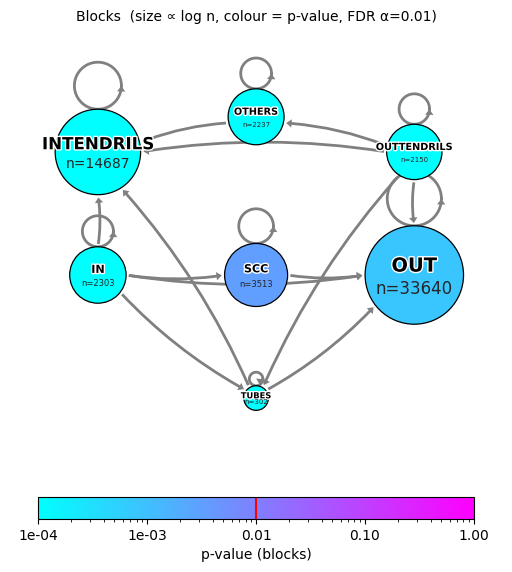

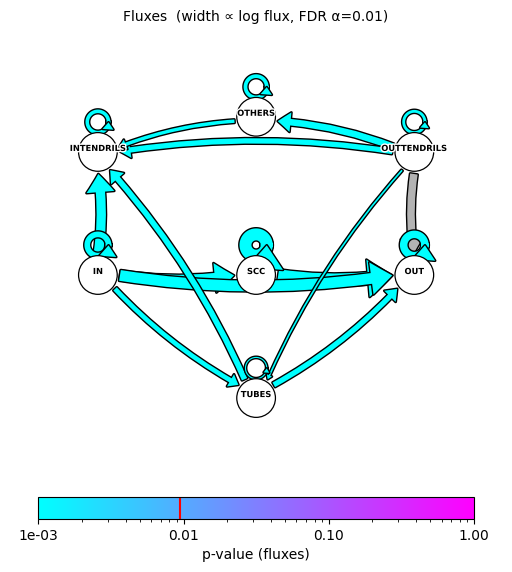

In [29]:

_plot_block = plot_bowtie_blocks(block_dict_0[dataset]['p_vals'], fluxes_dict_0[dataset]['p_vals'], 0.01)
_plot_flux = plot_bowtie_fluxes(fluxes_dict_0[dataset]['p_vals'], 0.01)
bow_tie_figs=[_plot_block, _plot_flux]
for bow_tie_fig in bow_tie_figs:
    #plt.savefig(TEST_FOLDER + f"/{dataset}_bowtie_plot.png", dpi=300)
    plt.show()


### Right-tail tests

In [30]:
for key, item in block_dict_0[dataset]['p_vals'].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OUT: p-value=8.00e-04, tail=left
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=3.20e-03, tail=right
OUTTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
IN: p-value=0.00e+00, tail=left
TUBES: p-value=0.00e+00, tail=right


In [31]:
for key, item in fluxes_dict_0[dataset]['p_vals'].items():
    if item['tail']=='right':
        print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

('SCC', 'SCC'): p-value=0.00e+00, tail=right
('SCC', 'OUT'): p-value=0.00e+00, tail=right
('IN', 'INTENDRILS'): p-value=0.00e+00, tail=right
('IN', 'TUBES'): p-value=0.00e+00, tail=right
('OUT', 'OUT'): p-value=0.00e+00, tail=right
('IN', 'IN'): p-value=0.00e+00, tail=right
('OUTTENDRILS', 'OTHERS'): p-value=0.00e+00, tail=right
('OUTTENDRILS', 'OUT'): p-value=5.24e-02, tail=right
('OUTTENDRILS', 'INTENDRILS'): p-value=0.00e+00, tail=right
('OUTTENDRILS', 'OUTTENDRILS'): p-value=0.00e+00, tail=right
('INTENDRILS', 'INTENDRILS'): p-value=0.00e+00, tail=right
('TUBES', 'INTENDRILS'): p-value=0.00e+00, tail=right
('OUTTENDRILS', 'TUBES'): p-value=0.00e+00, tail=right
('OTHERS', 'OTHERS'): p-value=0.00e+00, tail=right
('TUBES', 'TUBES'): p-value=0.00e+00, tail=right
('OTHERS', 'INTENDRILS'): p-value=0.00e+00, tail=right


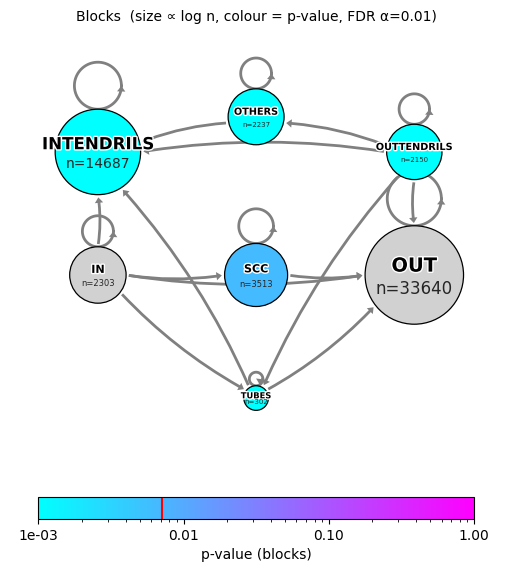

In [32]:
# just the right tailed blocks with FDR validation
right_tailed_blocks={}
for key, item in block_dict_0[dataset]['p_vals'].items():
    right_tailed_blocks[key] = item
    if item['tail'] == 'right':
        right_tailed_blocks[key]['p_value'] *=2
    else:
        right_tailed_blocks[key]['p_value']=1.
plot_bowtie_blocks(right_tailed_blocks, fluxes_dict_0[dataset]['p_vals'], 0.01)
plt.show()

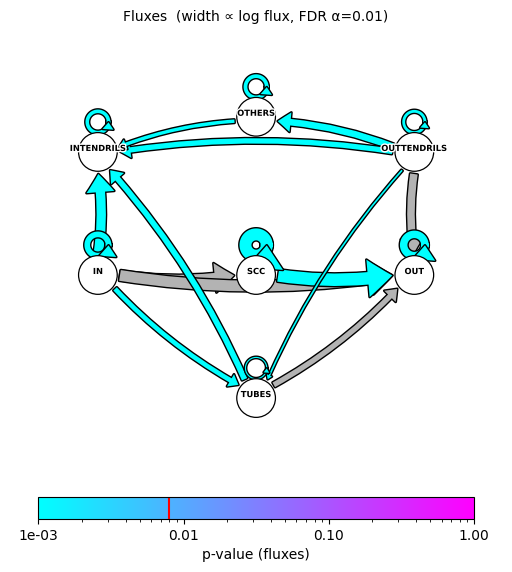

In [33]:
# just the right tailed fluxes with FDR validation
right_tailed_fluxes={}
for key, item in fluxes_dict_0[dataset]['p_vals'].items():
    right_tailed_fluxes[key] = item
    if item['tail'] == 'right':
        right_tailed_fluxes[key]['p_value'] *=2
    else:
        right_tailed_fluxes[key]['p_value']=1.
plot_bowtie_fluxes(right_tailed_fluxes, 0.01)
plt.show()

#### Summarising

Considering Crisis DiCo 0, I would say that the main process is a one-step, as the right-tail validated fluxes are between sources (i.e. IN, OUTTENDRILS and even SCC and TUBES) and sinks (i.e. INTENDRILS and OUT). Furthermore, the only signal of two-steps seems to be using TUBES as medium.   
Such an interpretation is corroborated from the two-tails tests, stating that 1. the dimensions of IN and OUT is significantly smaller than expected and 2. the flux between IN and SCC and between IN and OUT are significantly smaller than expected.

## Crisi, DiCo 1 example

### Two-tails tests

In [28]:
dataset = list(block_dict_0.keys())[1]
print(f"Plotting: {dataset}")   

Plotting: crisi_dico1


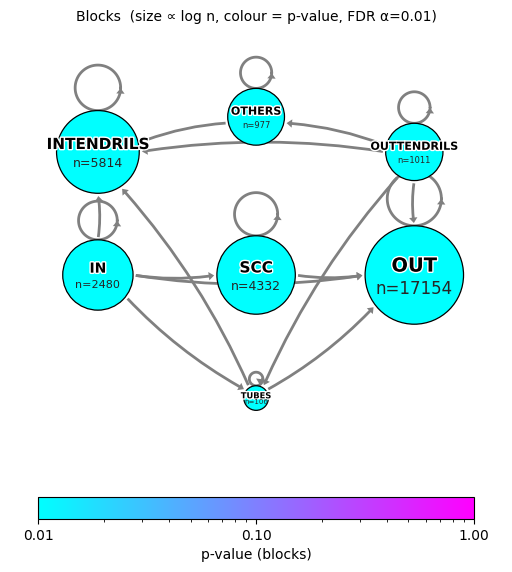

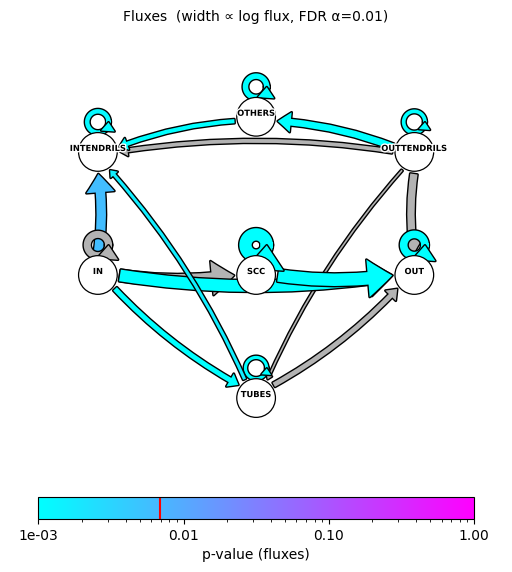

In [29]:

_plot_block = plot_bowtie_blocks(block_dict_0[dataset]['p_vals'], fluxes_dict_0[dataset]['p_vals'], 0.01)
_plot_flux = plot_bowtie_fluxes(fluxes_dict_0[dataset]['p_vals'], 0.01)
bow_tie_figs=[_plot_block, _plot_flux]
for bow_tie_fig in bow_tie_figs:
    #plt.savefig(TEST_FOLDER + f"/{dataset}_bowtie_plot.png", dpi=300)
    plt.show()


### Right-tail tests

In [30]:
for key, item in block_dict_0[dataset]['p_vals'].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OUT: p-value=0.00e+00, tail=left
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
IN: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [31]:
for key, item in fluxes_dict_0[dataset]['p_vals'].items():
    if item['tail']=='right':
        print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

('IN', 'OUT'): p-value=0.00e+00, tail=right
('IN', 'SCC'): p-value=2.92e-02, tail=right
('IN', 'INTENDRILS'): p-value=6.00e-03, tail=right
('IN', 'IN'): p-value=7.32e-02, tail=right
('IN', 'TUBES'): p-value=0.00e+00, tail=right
('SCC', 'SCC'): p-value=0.00e+00, tail=right
('SCC', 'OUT'): p-value=0.00e+00, tail=right
('OUT', 'OUT'): p-value=0.00e+00, tail=right
('OUTTENDRILS', 'OUT'): p-value=9.60e-03, tail=right
('OUTTENDRILS', 'OTHERS'): p-value=0.00e+00, tail=right
('OUTTENDRILS', 'INTENDRILS'): p-value=1.64e-02, tail=right
('OUTTENDRILS', 'OUTTENDRILS'): p-value=0.00e+00, tail=right
('OTHERS', 'OTHERS'): p-value=0.00e+00, tail=right
('OTHERS', 'INTENDRILS'): p-value=0.00e+00, tail=right
('INTENDRILS', 'INTENDRILS'): p-value=1.20e-03, tail=right
('TUBES', 'OUT'): p-value=2.56e-02, tail=right
('TUBES', 'TUBES'): p-value=0.00e+00, tail=right
('TUBES', 'INTENDRILS'): p-value=1.60e-03, tail=right
('OUTTENDRILS', 'TUBES'): p-value=7.12e-02, tail=right


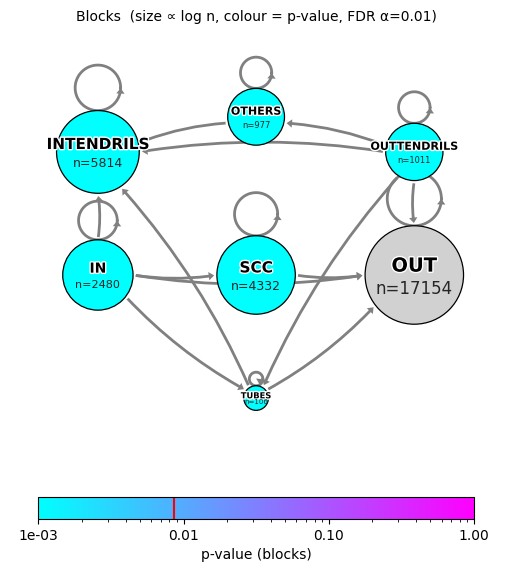

In [32]:
# just the right tailed blocks with FDR validation
right_tailed_blocks={}
for key, item in block_dict_0[dataset]['p_vals'].items():
    right_tailed_blocks[key] = item
    if item['tail'] == 'right':
        right_tailed_blocks[key]['p_value'] *=2
    else:
        right_tailed_blocks[key]['p_value']=1.
plot_bowtie_blocks(right_tailed_blocks, fluxes_dict_0[dataset]['p_vals'], 0.01)
plt.show()

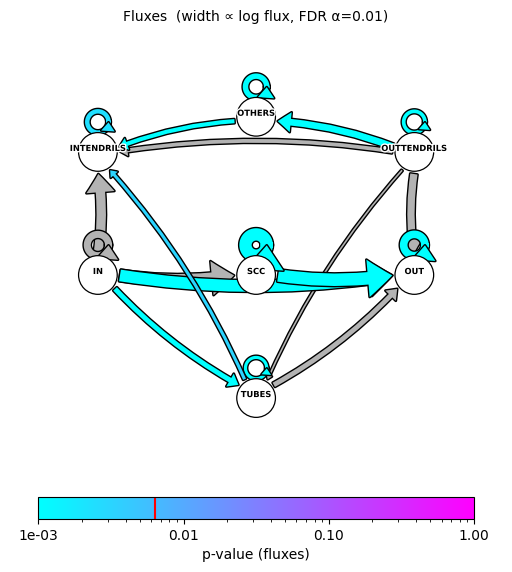

In [33]:
# just the right tailed fluxes with FDR validation
right_tailed_fluxes={}
for key, item in fluxes_dict_0[dataset]['p_vals'].items():
    right_tailed_fluxes[key] = item
    if item['tail'] == 'right':
        right_tailed_fluxes[key]['p_value'] *=2
    else:
        right_tailed_fluxes[key]['p_value']=1.
plot_bowtie_fluxes(right_tailed_fluxes, 0.01)
plt.show()

#### Summarising

Considering Crisis DiCo 1, I would say that the main process is a two-step, as the right-tail validated fluxes are between mediators (i.e. TUBES and SCC) and sinks (i.e. INTENDRILS and OUT), while direct fluxes from sources to sinks are validated only in the IN to OUT case. In this picture, the only evidence clashing is that in the two-tails validation, the dimensions of OUT is statistically significant, but it is on the left tail (i.e. it is much **smaller** than expected), while in a proper two-step picture it would have been either in line with the expaction or even greater.

## Crisi, DiCo 2 example

### Two-tails tests

In [34]:
dataset = list(block_dict_0.keys())[2]
print(f"Plotting: {dataset}")   

Plotting: crisi_dico2


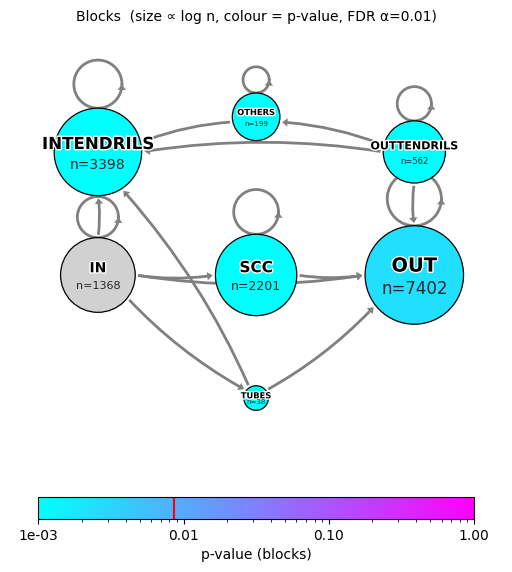

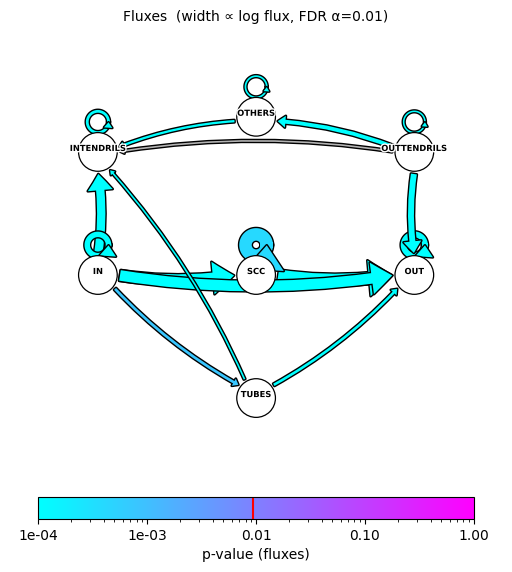

In [35]:

_plot_block = plot_bowtie_blocks(block_dict_0[dataset]['p_vals'], fluxes_dict_0[dataset]['p_vals'], 0.01)
_plot_flux = plot_bowtie_fluxes(fluxes_dict_0[dataset]['p_vals'], 0.01)
bow_tie_figs=[_plot_block, _plot_flux]
for bow_tie_fig in bow_tie_figs:
    #plt.savefig(TEST_FOLDER + f"/{dataset}_bowtie_plot.png", dpi=300)
    plt.show()


### Right-tail tests

In [36]:
for key, item in block_dict_0[dataset]['p_vals'].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

INTENDRILS: p-value=0.00e+00, tail=right
OUT: p-value=2.40e-03, tail=left
IN: p-value=2.84e-02, tail=left
OTHERS: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [37]:
for key, item in fluxes_dict_0[dataset]['p_vals'].items():
    if item['tail']=='right':
        print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

('SCC', 'OUT'): p-value=0.00e+00, tail=right
('SCC', 'SCC'): p-value=4.00e-04, tail=right
('IN', 'SCC'): p-value=0.00e+00, tail=right
('IN', 'OUT'): p-value=0.00e+00, tail=right
('IN', 'INTENDRILS'): p-value=0.00e+00, tail=right
('IN', 'IN'): p-value=0.00e+00, tail=right
('IN', 'TUBES'): p-value=8.00e-04, tail=right
('OUT', 'OUT'): p-value=0.00e+00, tail=right
('OTHERS', 'INTENDRILS'): p-value=0.00e+00, tail=right
('OTHERS', 'OTHERS'): p-value=0.00e+00, tail=right
('OUTTENDRILS', 'OUT'): p-value=0.00e+00, tail=right
('INTENDRILS', 'INTENDRILS'): p-value=0.00e+00, tail=right
('TUBES', 'OUT'): p-value=0.00e+00, tail=right
('TUBES', 'INTENDRILS'): p-value=0.00e+00, tail=right
('OUTTENDRILS', 'OTHERS'): p-value=0.00e+00, tail=right
('OUTTENDRILS', 'OUTTENDRILS'): p-value=0.00e+00, tail=right
('OUTTENDRILS', 'INTENDRILS'): p-value=5.28e-02, tail=right


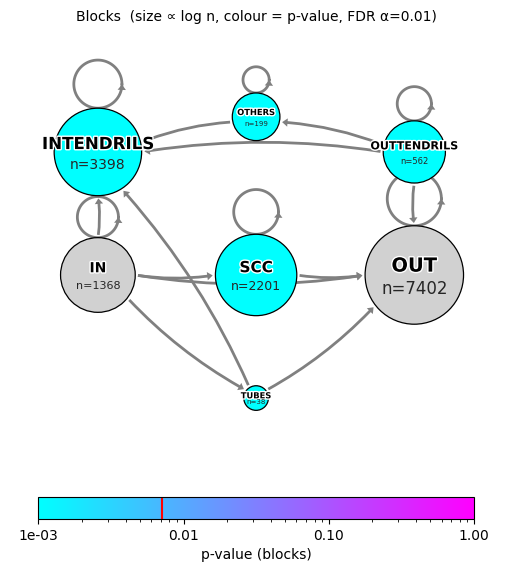

In [38]:
# just the right tailed blocks with FDR validation
right_tailed_blocks={}
for key, item in block_dict_0[dataset]['p_vals'].items():
    right_tailed_blocks[key] = item
    if item['tail'] == 'right':
        right_tailed_blocks[key]['p_value'] *=2
    else:
        right_tailed_blocks[key]['p_value']=1.
plot_bowtie_blocks(right_tailed_blocks, fluxes_dict_0[dataset]['p_vals'], 0.01)
plt.show()

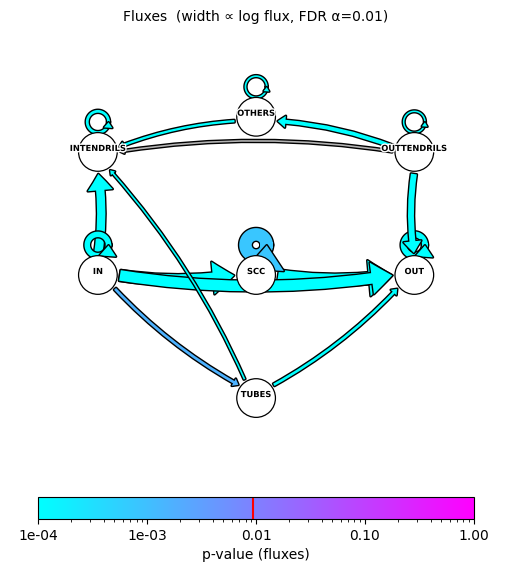

In [39]:
# just the right tailed fluxes with FDR validation
right_tailed_fluxes={}
for key, item in fluxes_dict_0[dataset]['p_vals'].items():
    right_tailed_fluxes[key] = item
    if item['tail'] == 'right':
        right_tailed_fluxes[key]['p_value'] *=2
    else:
        right_tailed_fluxes[key]['p_value']=1.
plot_bowtie_fluxes(right_tailed_fluxes, 0.01)
plt.show()

#### Summarising

Results are similar to DiCo 1, essentially.

## Crisi, DiCo 3 example

### Two-tails tests

In [40]:
dataset = list(block_dict_0.keys())[3]
print(f"Plotting: {dataset}")   

Plotting: crisi_dico3


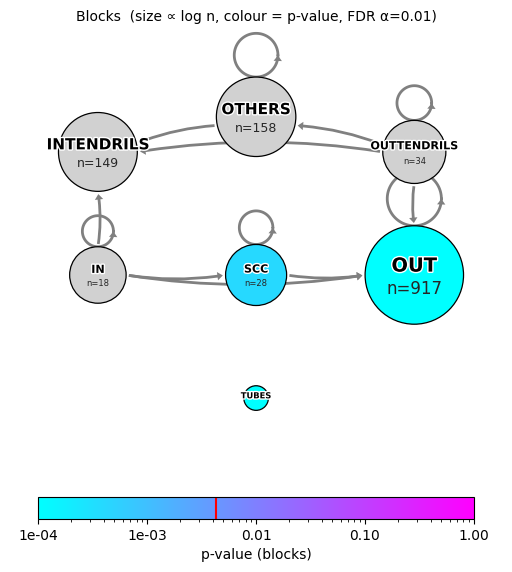

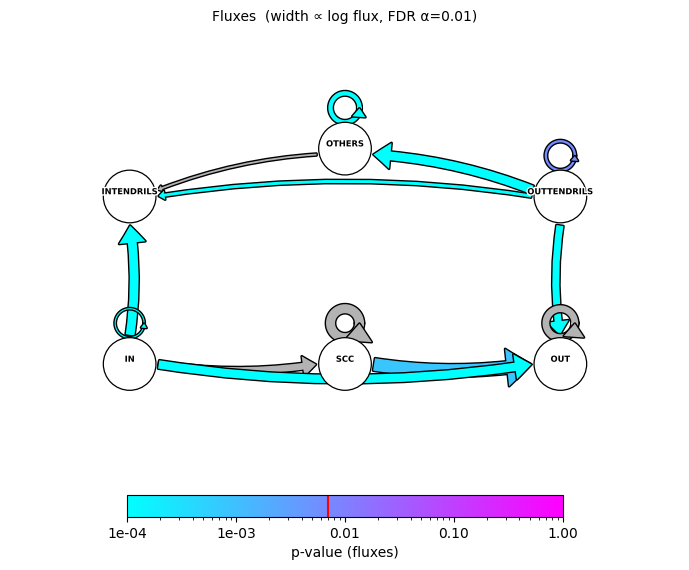

In [41]:

_plot_block = plot_bowtie_blocks(block_dict_0[dataset]['p_vals'], fluxes_dict_0[dataset]['p_vals'], 0.01)
_plot_flux = plot_bowtie_fluxes(fluxes_dict_0[dataset]['p_vals'], 0.01)
bow_tie_figs=[_plot_block, _plot_flux]
for bow_tie_fig in bow_tie_figs:
    #plt.savefig(TEST_FOLDER + f"/{dataset}_bowtie_plot.png", dpi=300)
    plt.show()


### Right-tail tests

In [42]:
for key, item in block_dict_0[dataset]['p_vals'].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OUT: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=3.34e-01, tail=right
SCC: p-value=4.00e-04, tail=right
INTENDRILS: p-value=8.06e-01, tail=left
OTHERS: p-value=6.80e-03, tail=right
IN: p-value=2.73e-01, tail=left
TUBES: p-value=0.00e+00, tail=left


In [43]:
for key, item in fluxes_dict_0[dataset]['p_vals'].items():
    if item['tail']=='right':
        print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

('SCC', 'OUT'): p-value=8.00e-04, tail=right
('SCC', 'SCC'): p-value=4.24e-02, tail=right
('OUTTENDRILS', 'OTHERS'): p-value=0.00e+00, tail=right
('OUTTENDRILS', 'OUTTENDRILS'): p-value=6.40e-03, tail=right
('OUT', 'OUT'): p-value=1.18e-01, tail=right
('IN', 'INTENDRILS'): p-value=0.00e+00, tail=right
('IN', 'SCC'): p-value=4.54e-01, tail=right
('OTHERS', 'OTHERS'): p-value=0.00e+00, tail=right
('IN', 'IN'): p-value=0.00e+00, tail=right
('OTHERS', 'INTENDRILS'): p-value=5.84e-01, tail=right


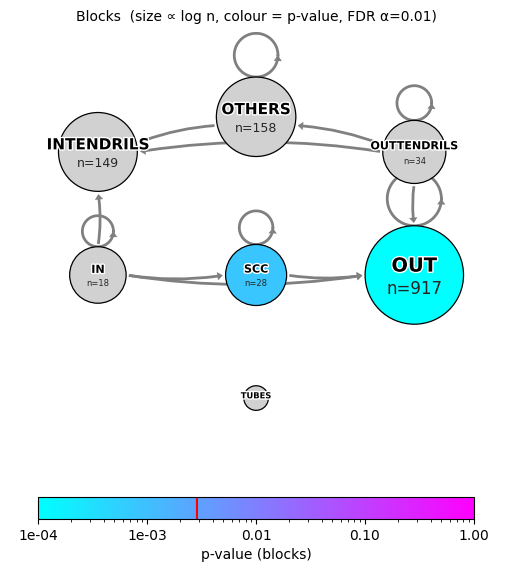

In [44]:
# just the right tailed blocks with FDR validation
right_tailed_blocks={}
for key, item in block_dict_0[dataset]['p_vals'].items():
    right_tailed_blocks[key] = item
    if item['tail'] == 'right':
        right_tailed_blocks[key]['p_value'] *=2
    else:
        right_tailed_blocks[key]['p_value']=1.
plot_bowtie_blocks(right_tailed_blocks, fluxes_dict_0[dataset]['p_vals'], 0.01)
plt.show()

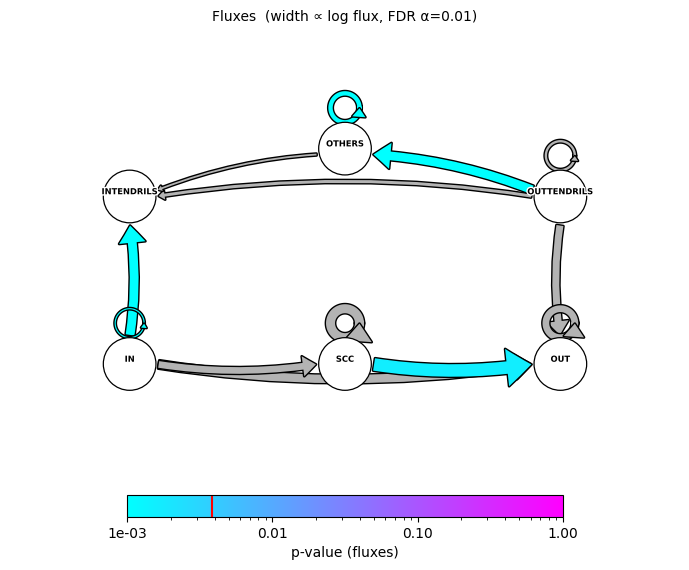

In [45]:
# just the right tailed fluxes with FDR validation
right_tailed_fluxes={}
for key, item in fluxes_dict_0[dataset]['p_vals'].items():
    right_tailed_fluxes[key] = item
    if item['tail'] == 'right':
        right_tailed_fluxes[key]['p_value'] *=2
    else:
        right_tailed_fluxes[key]['p_value']=1.
plot_bowtie_fluxes(right_tailed_fluxes, 0.01)
plt.show()

#### Summarising

I mean, PD. What else?

## Crisi, DiCo 4 example

### Two-tails tests

In [55]:
dataset = list(block_dict_0.keys())[4]
print(f"Plotting: {dataset}")   

Plotting: crisi_dico4


In [57]:
for key, value in block_dict_0[dataset]['p_vals'].items():
    print(f"{key}: observation={value['obs']}")

OTHERS: observation=3632
SCC: observation=3
OUTTENDRILS: observation=1
OUT: observation=1
INTENDRILS: observation=0
IN: observation=0
TUBES: observation=0


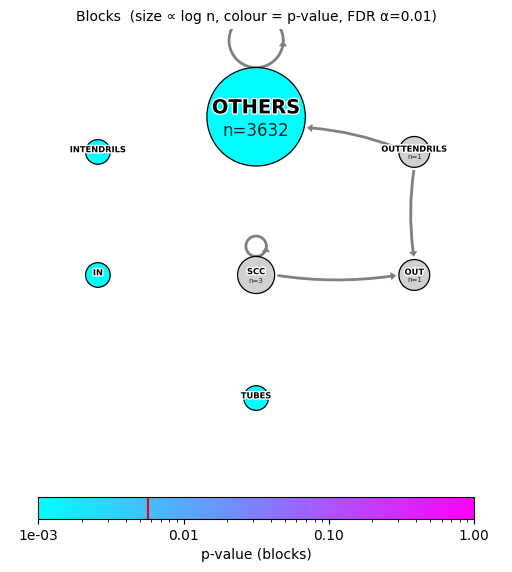

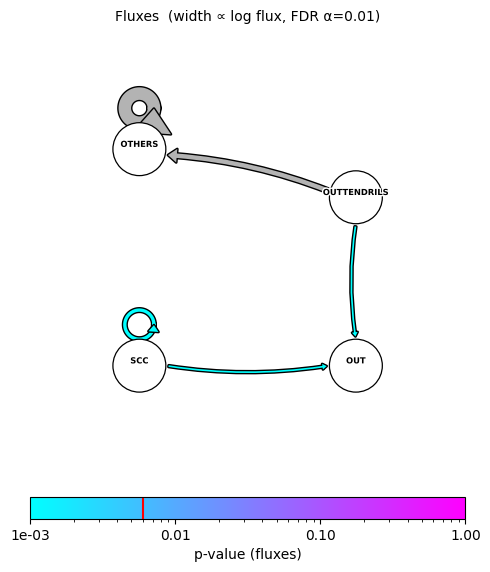

In [ ]:

_plot_block = plot_bowtie_blocks(block_dict_0[dataset]['p_vals'], fluxes_dict_0[dataset]['p_vals'], 0.01)
_plot_flux = plot_bowtie_fluxes(fluxes_dict_0[dataset]['p_vals'], 0.01)
bow_tie_figs=[_plot_block, _plot_flux]
for bow_tie_fig in bow_tie_figs:
    #plt.savefig(TEST_FOLDER + f"/{dataset}_bowtie_plot.png", dpi=300)
    plt.show()


The fact that in the first plot IN, INTENDRILS and TUBES are colored even if they do not have any link is due to the two-tail validation: their observed dimensions are exactly 0 and they are validated on the left-tail (it is significant do not observe any node in those classes). Thus the difference between the first and the second plots.

### Right-tail tests

In [48]:
for key, item in block_dict_0[dataset]['p_vals'].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OTHERS: p-value=0.00e+00, tail=right
SCC: p-value=2.24e-02, tail=right
OUTTENDRILS: p-value=1.32e-02, tail=left
OUT: p-value=5.12e-02, tail=left
INTENDRILS: p-value=0.00e+00, tail=left
IN: p-value=0.00e+00, tail=left
TUBES: p-value=0.00e+00, tail=left


In [49]:
for key, item in fluxes_dict_0[dataset]['p_vals'].items():
    if item['tail']=='right':
        print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

('OTHERS', 'OTHERS'): p-value=1.66e-01, tail=right
('OUTTENDRILS', 'OUT'): p-value=0.00e+00, tail=right
('SCC', 'OUT'): p-value=0.00e+00, tail=right
('SCC', 'SCC'): p-value=0.00e+00, tail=right


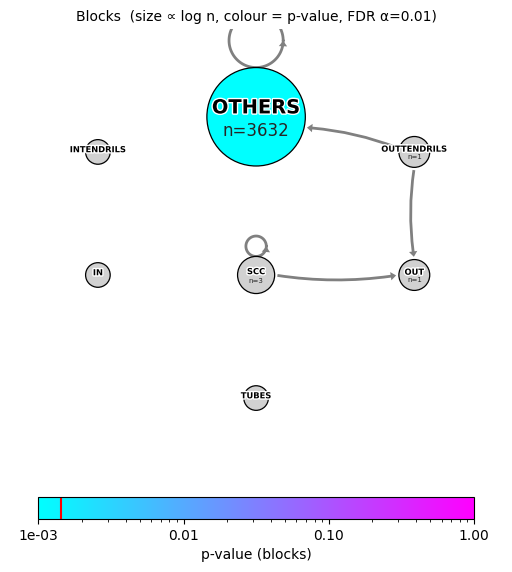

In [50]:
# just the right tailed blocks with FDR validation
right_tailed_blocks={}
for key, item in block_dict_0[dataset]['p_vals'].items():
    right_tailed_blocks[key] = item
    if item['tail'] == 'right':
        right_tailed_blocks[key]['p_value'] *=2
    else:
        right_tailed_blocks[key]['p_value']=1.
plot_bowtie_blocks(right_tailed_blocks, fluxes_dict_0[dataset]['p_vals'], 0.01)
plt.show()

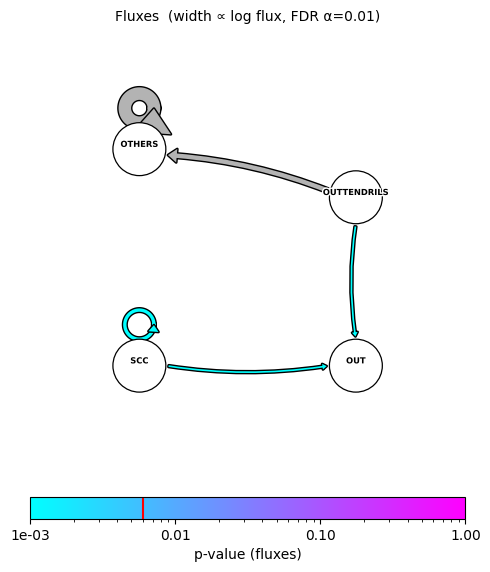

In [51]:
# just the right tailed fluxes with FDR validation
right_tailed_fluxes={}
for key, item in fluxes_dict_0[dataset]['p_vals'].items():
    right_tailed_fluxes[key] = item
    if item['tail'] == 'right':
        right_tailed_fluxes[key]['p_value'] *=2
    else:
        right_tailed_fluxes[key]['p_value']=1.
plot_bowtie_fluxes(right_tailed_fluxes, 0.01)
plt.show()

#### Summarising

As expected, the structure of News and Media is completely different from the standard. Remarkably 3 sectors (IN, INTENDRILS and TUBES) are completely absent from the original representation. 